# MODEL DEPLOYMENT

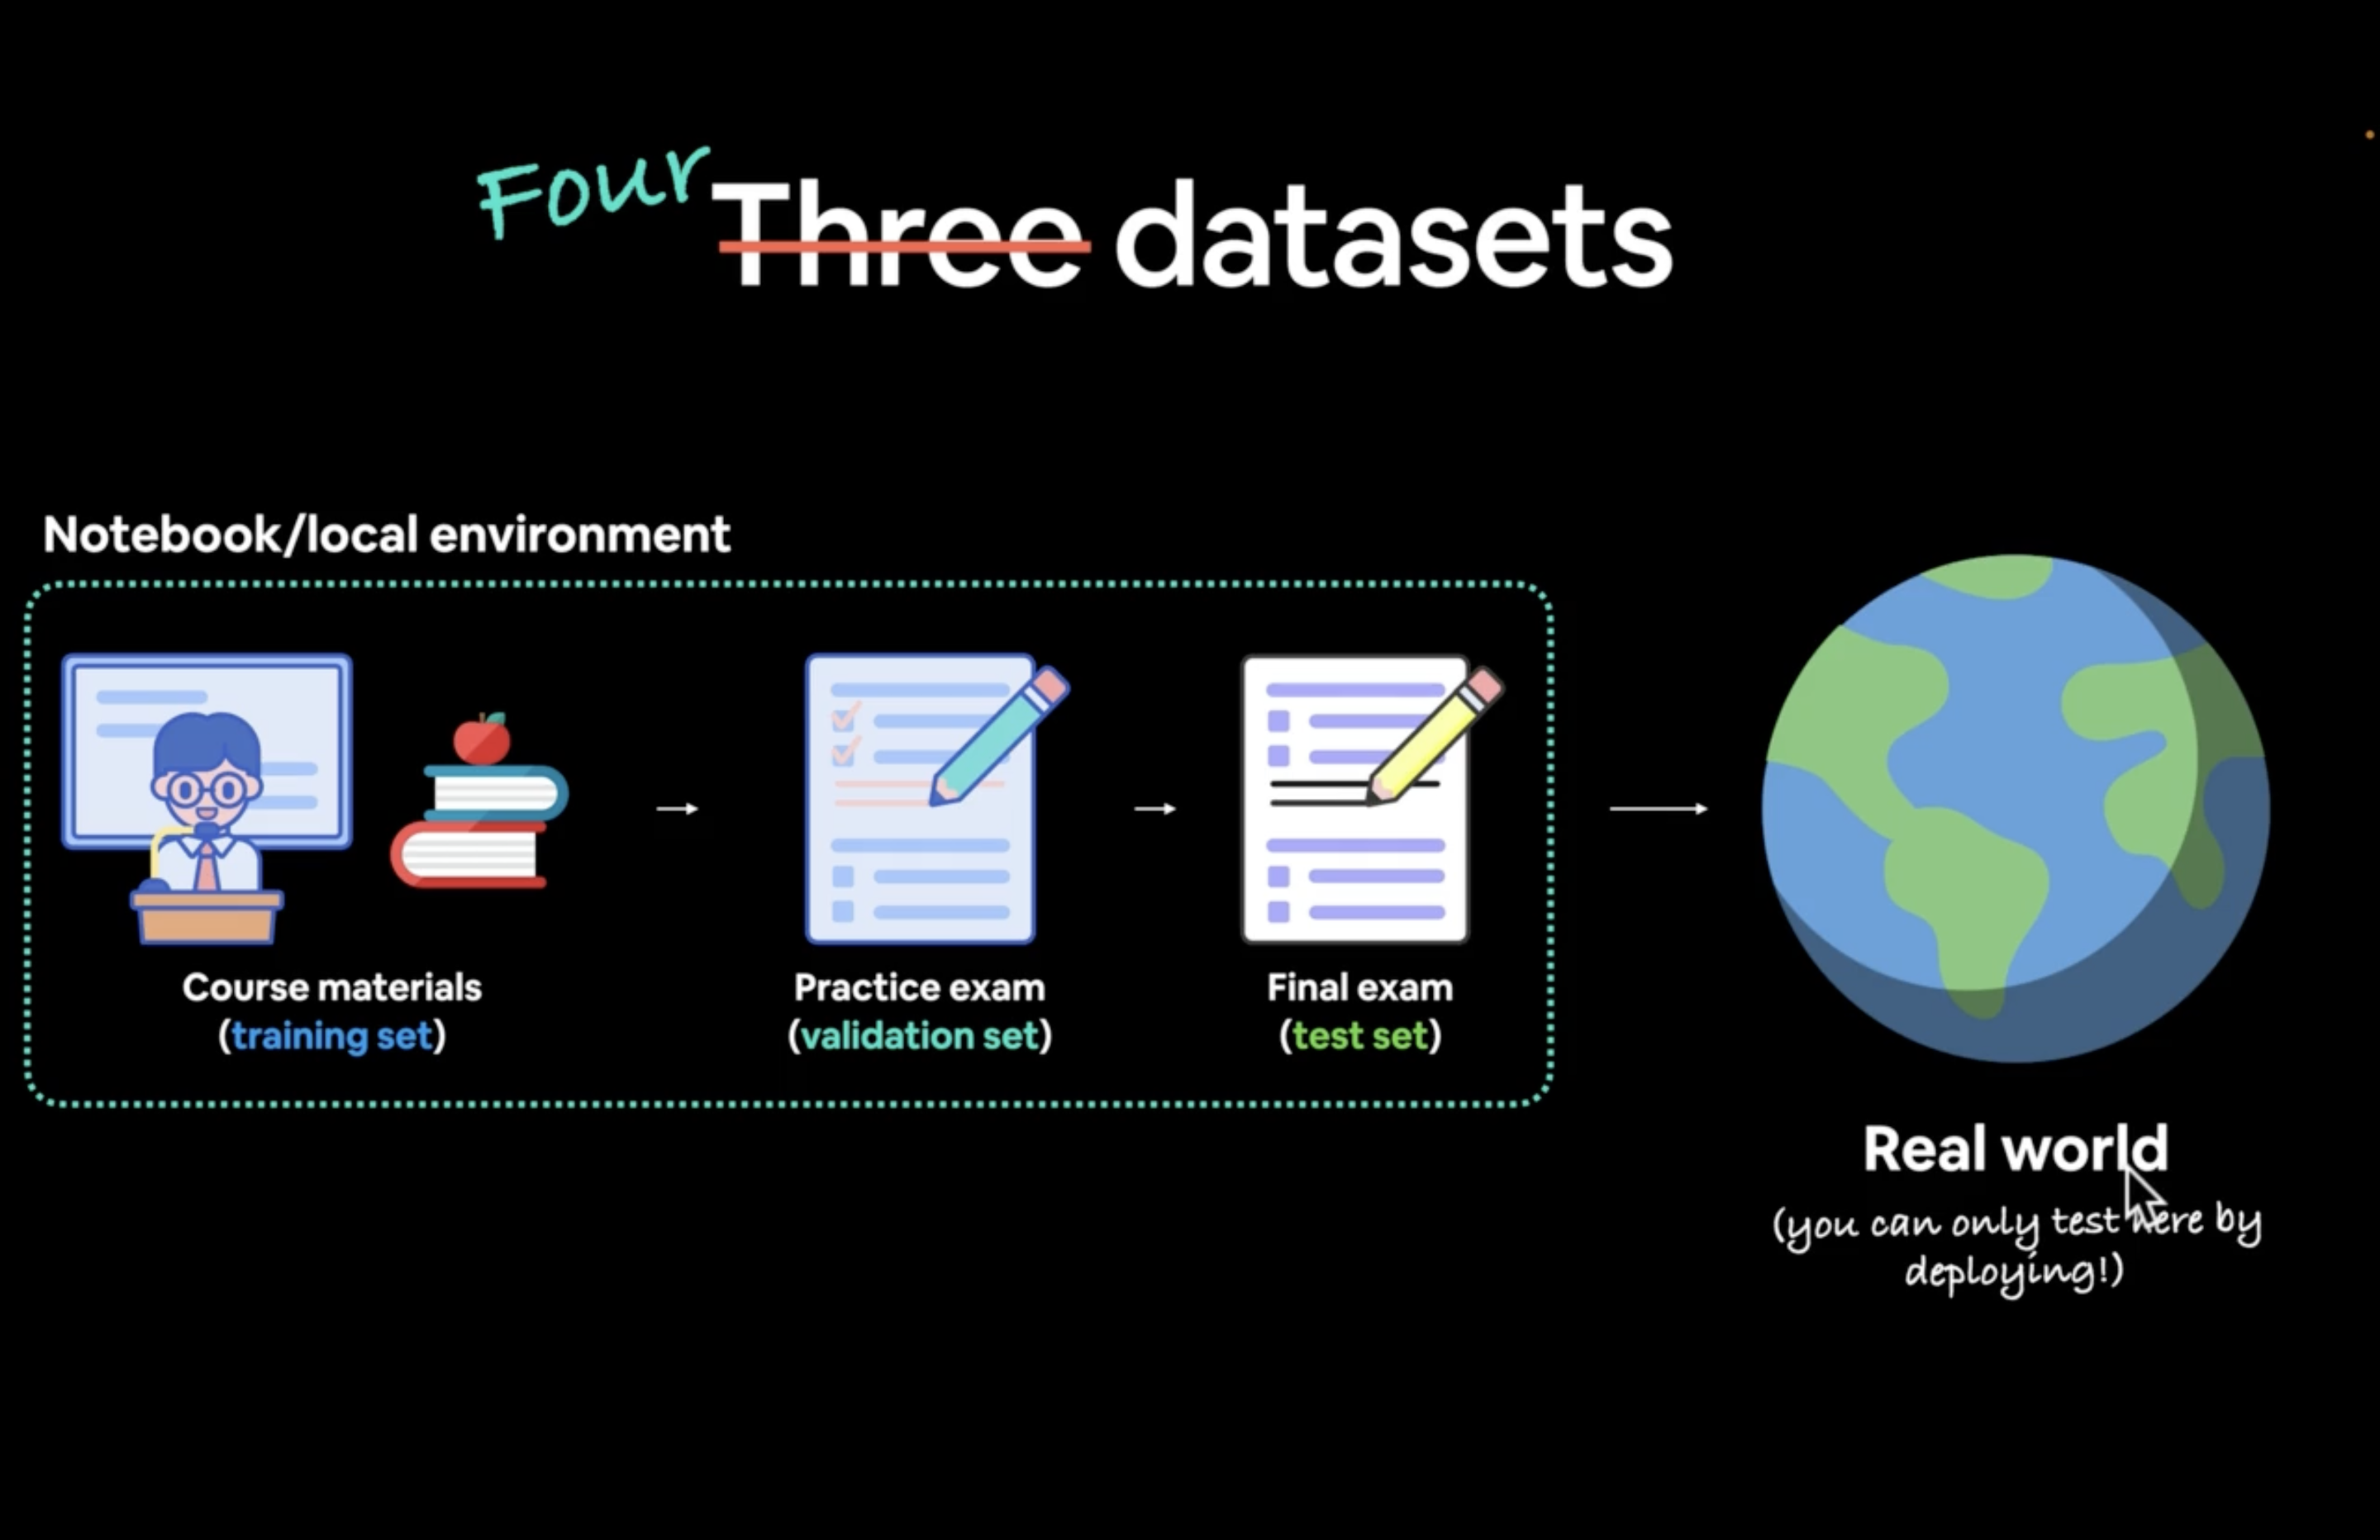

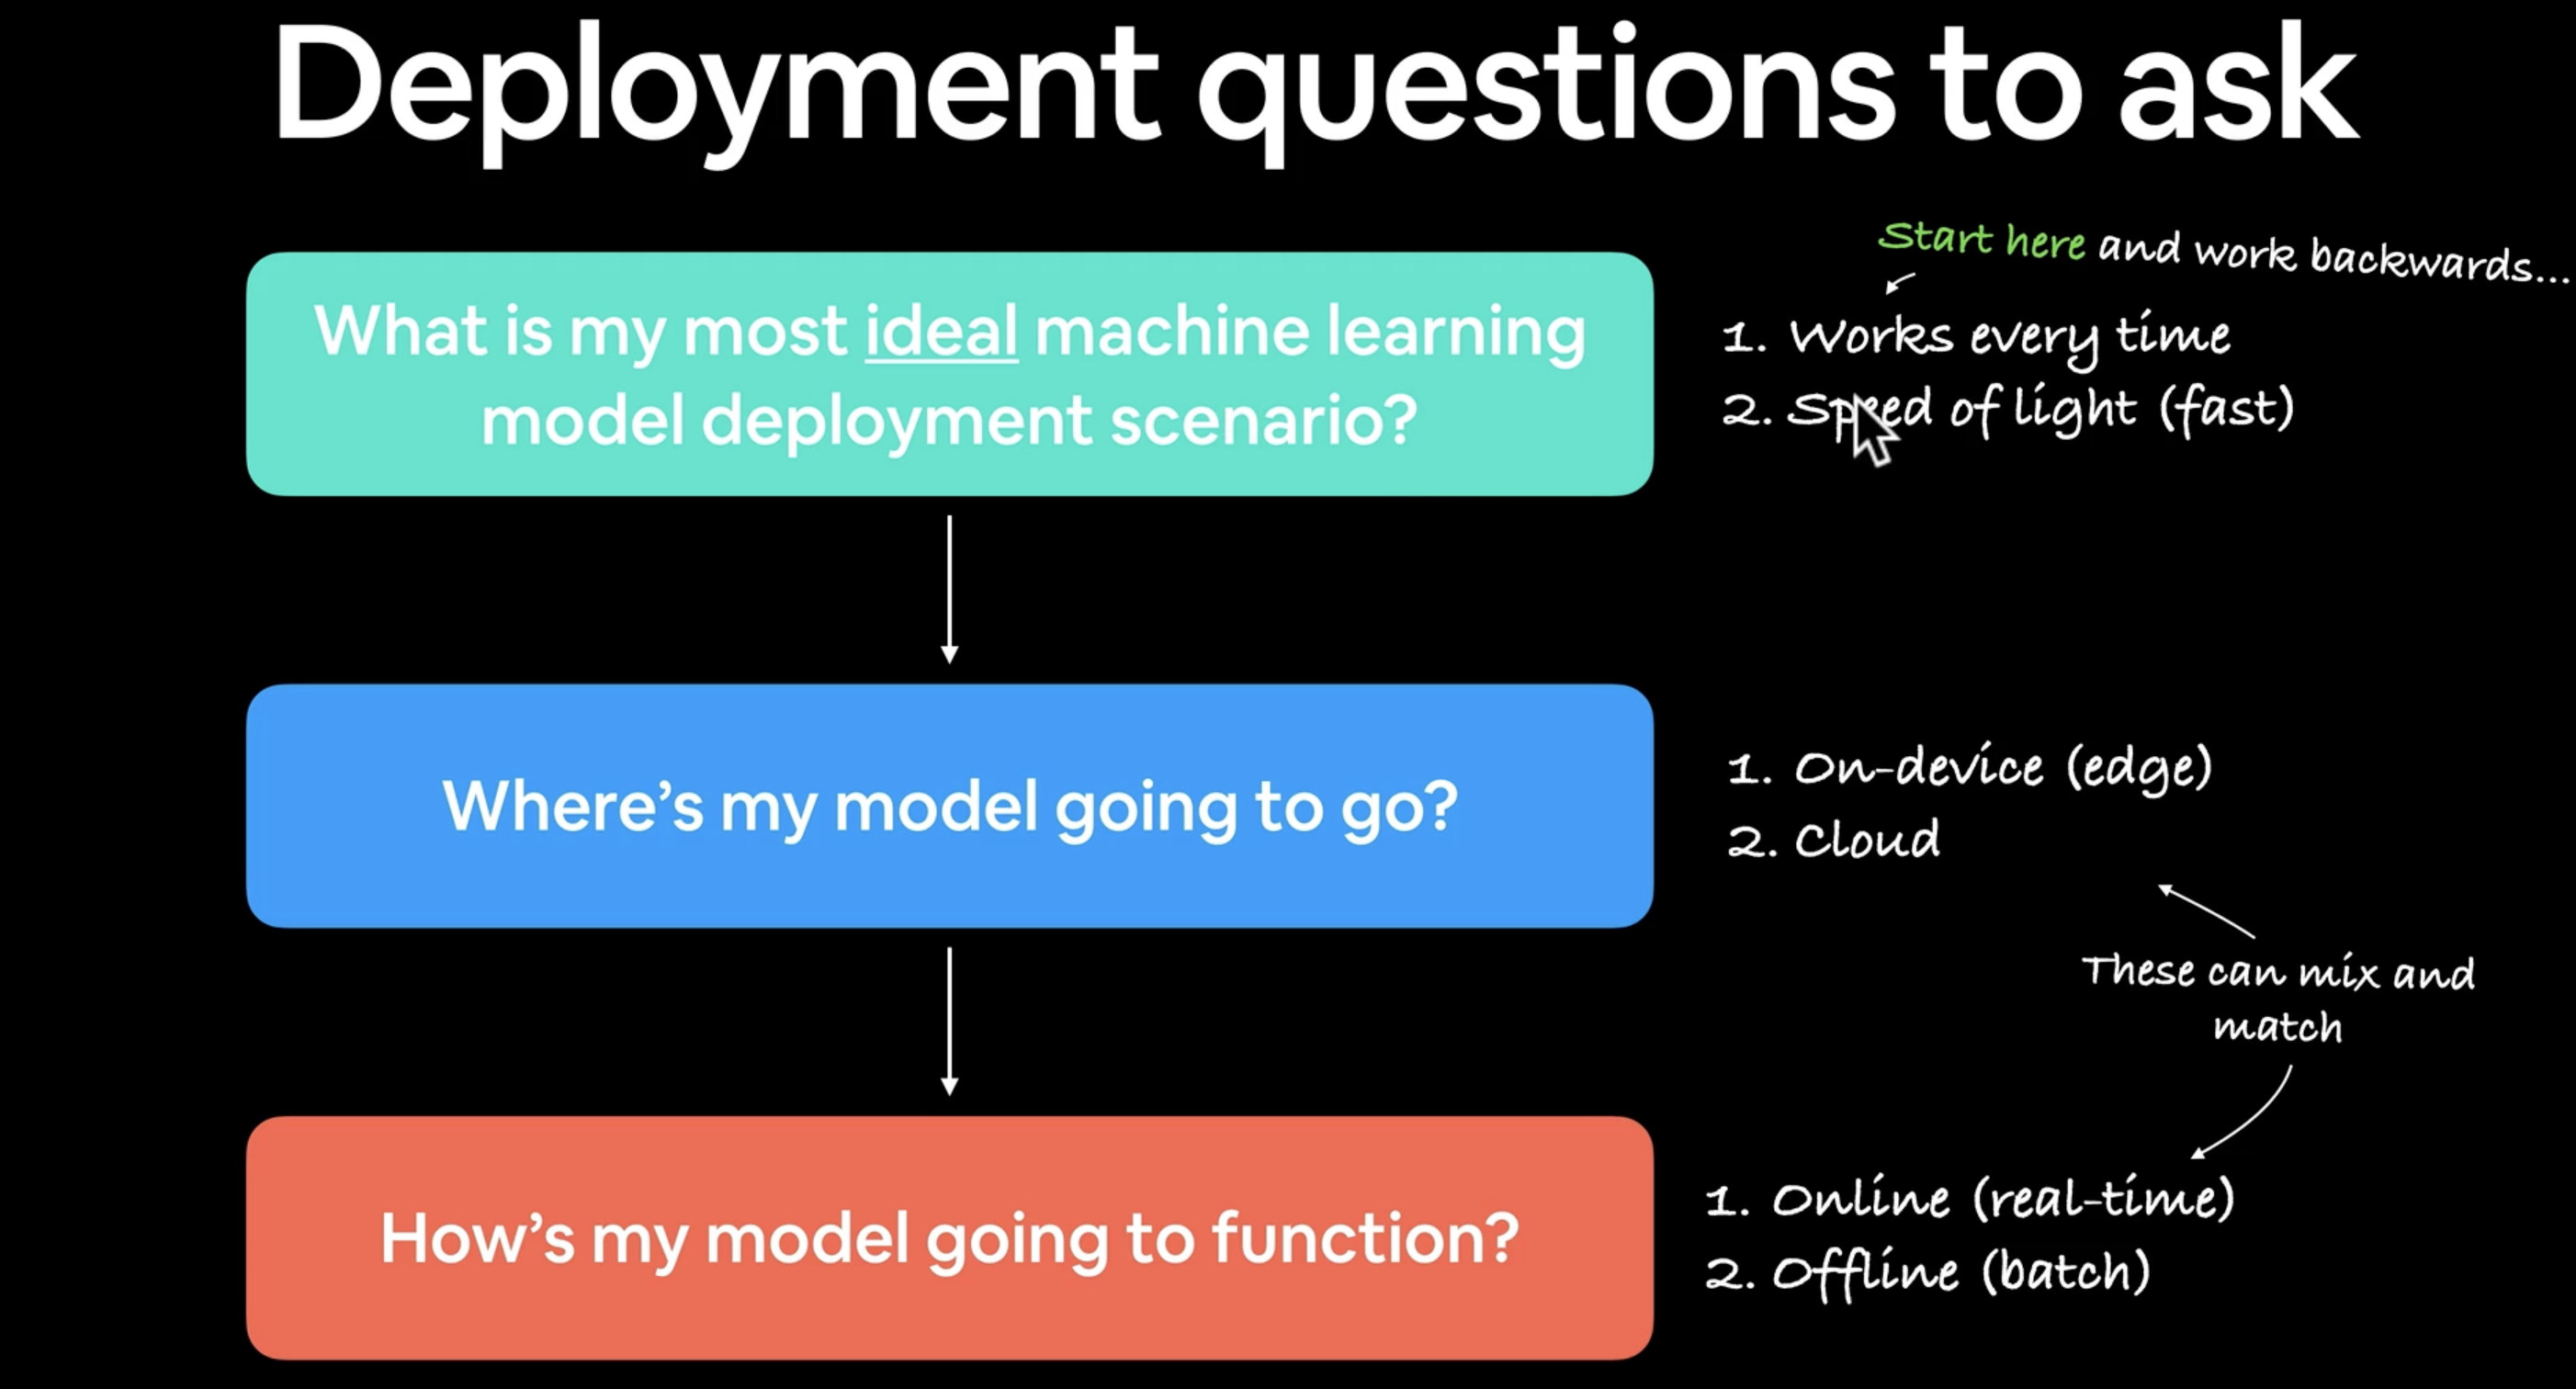

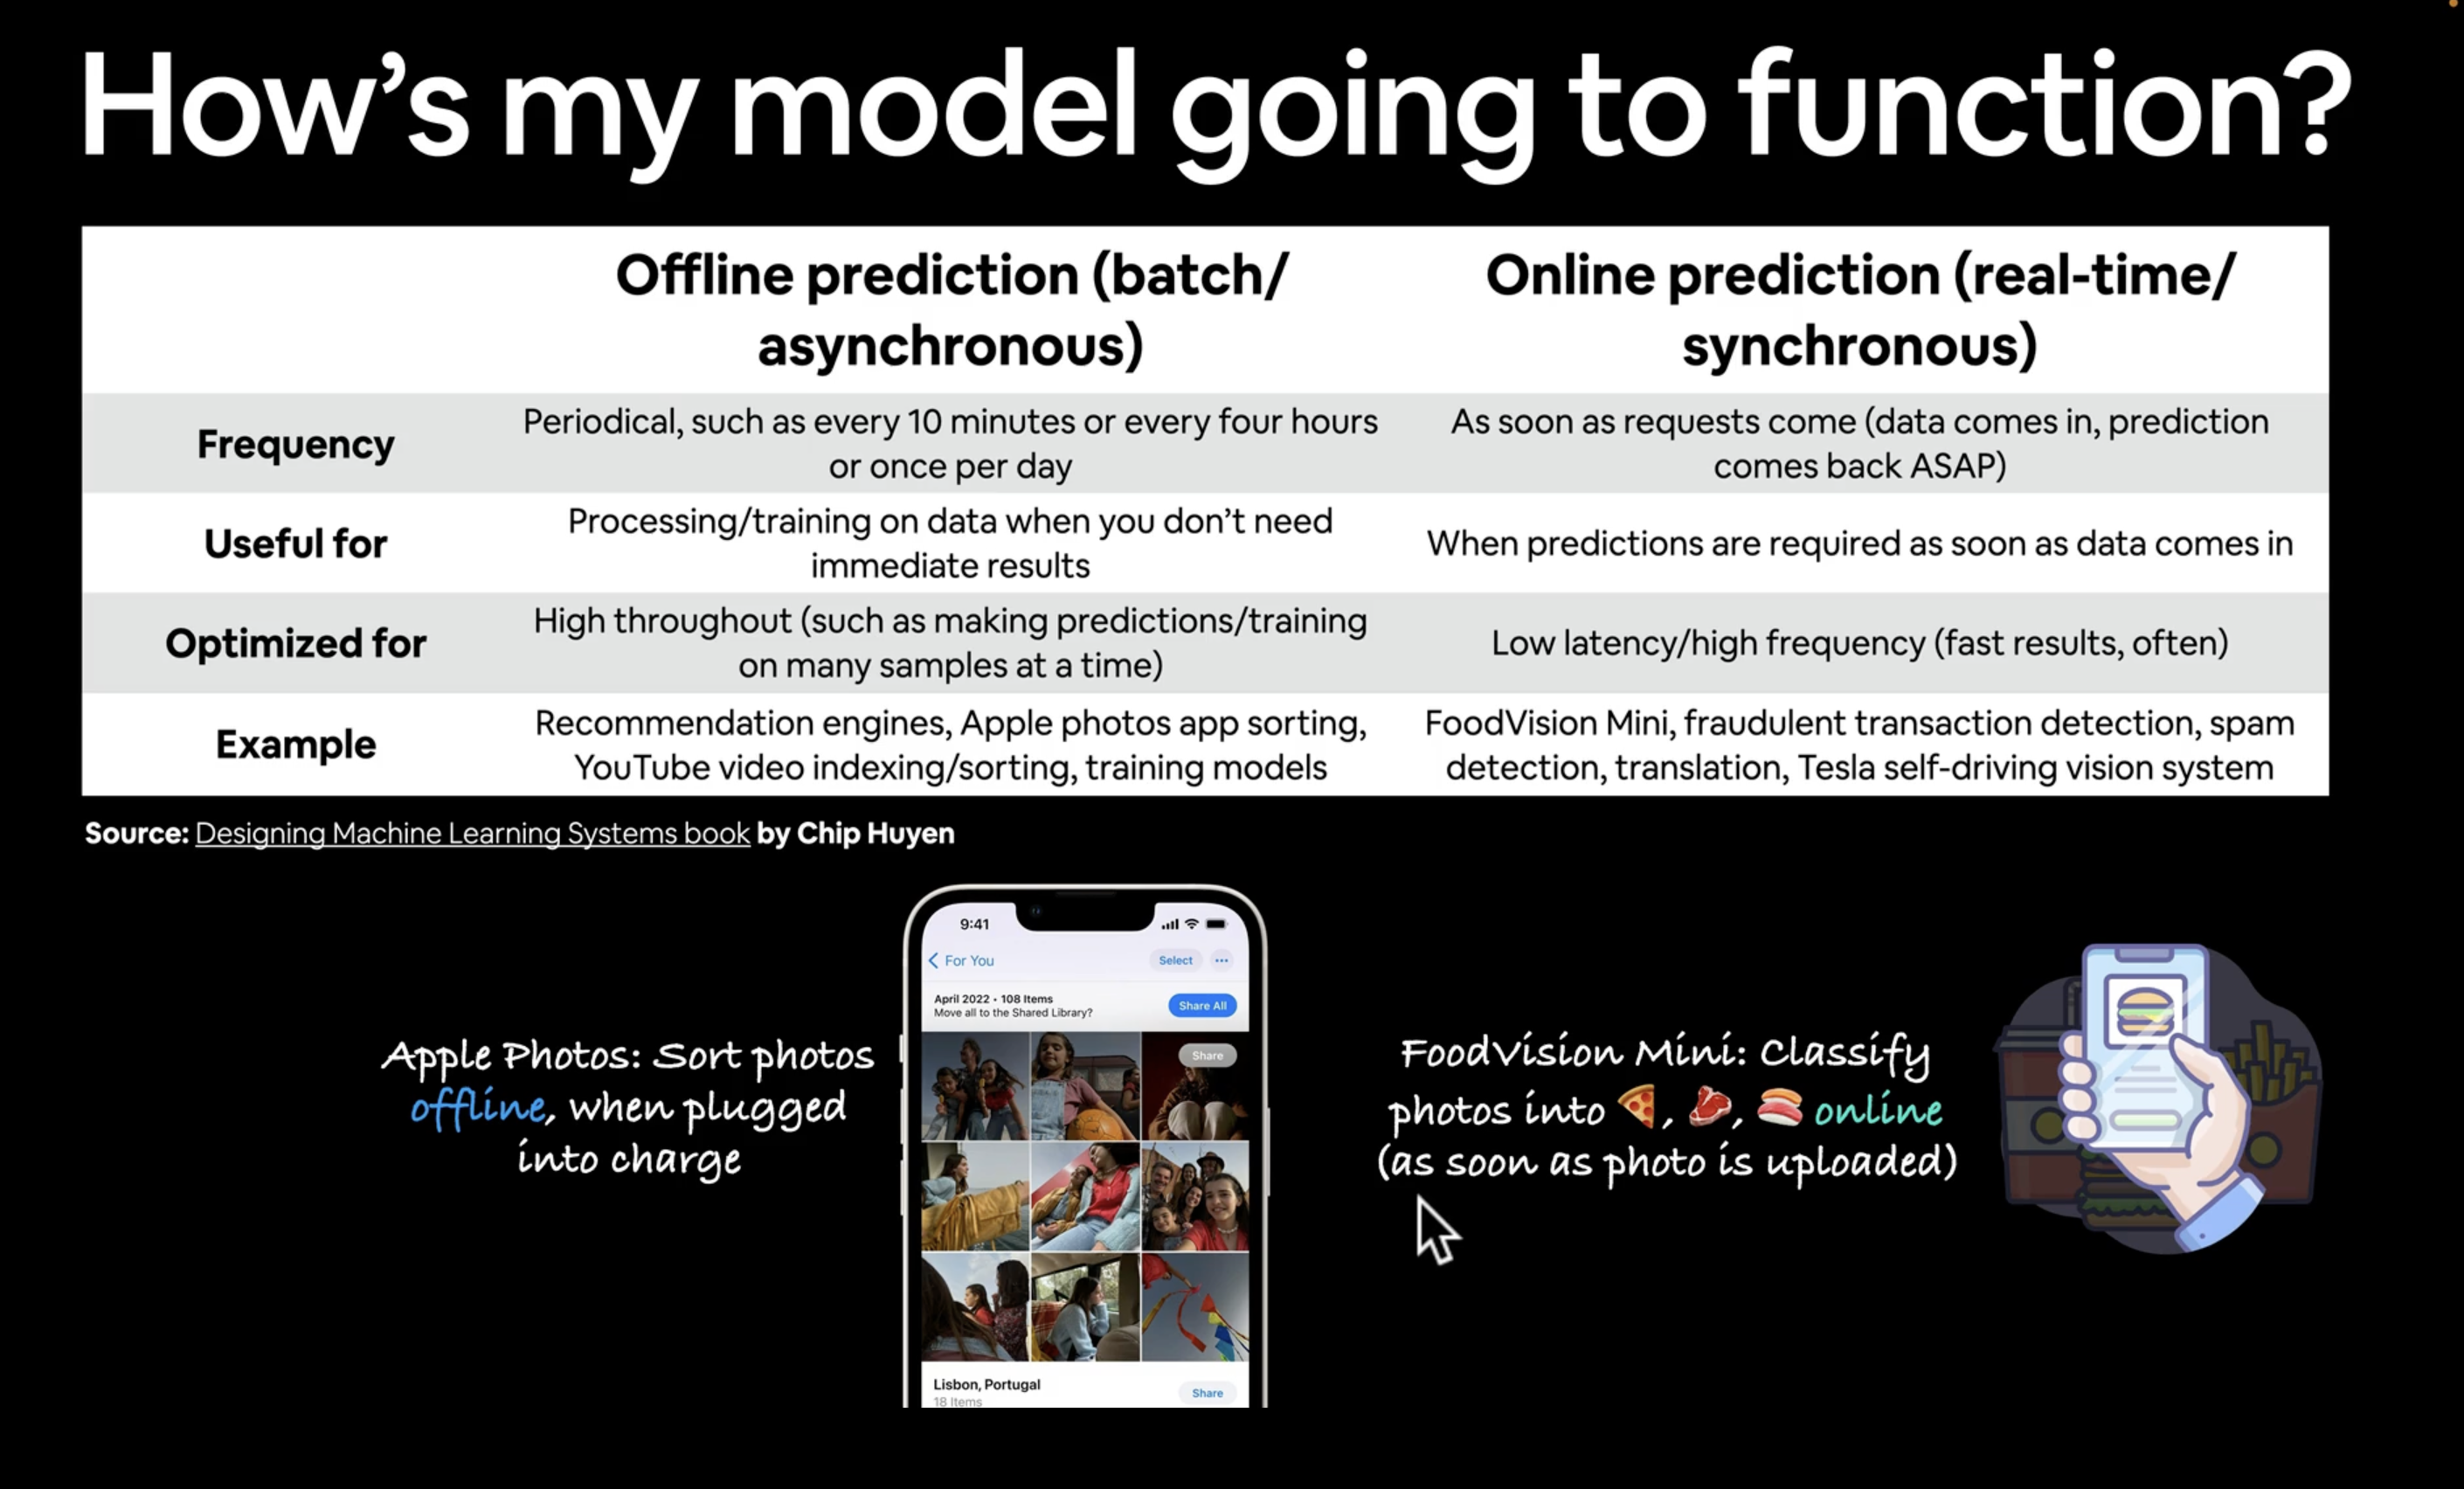

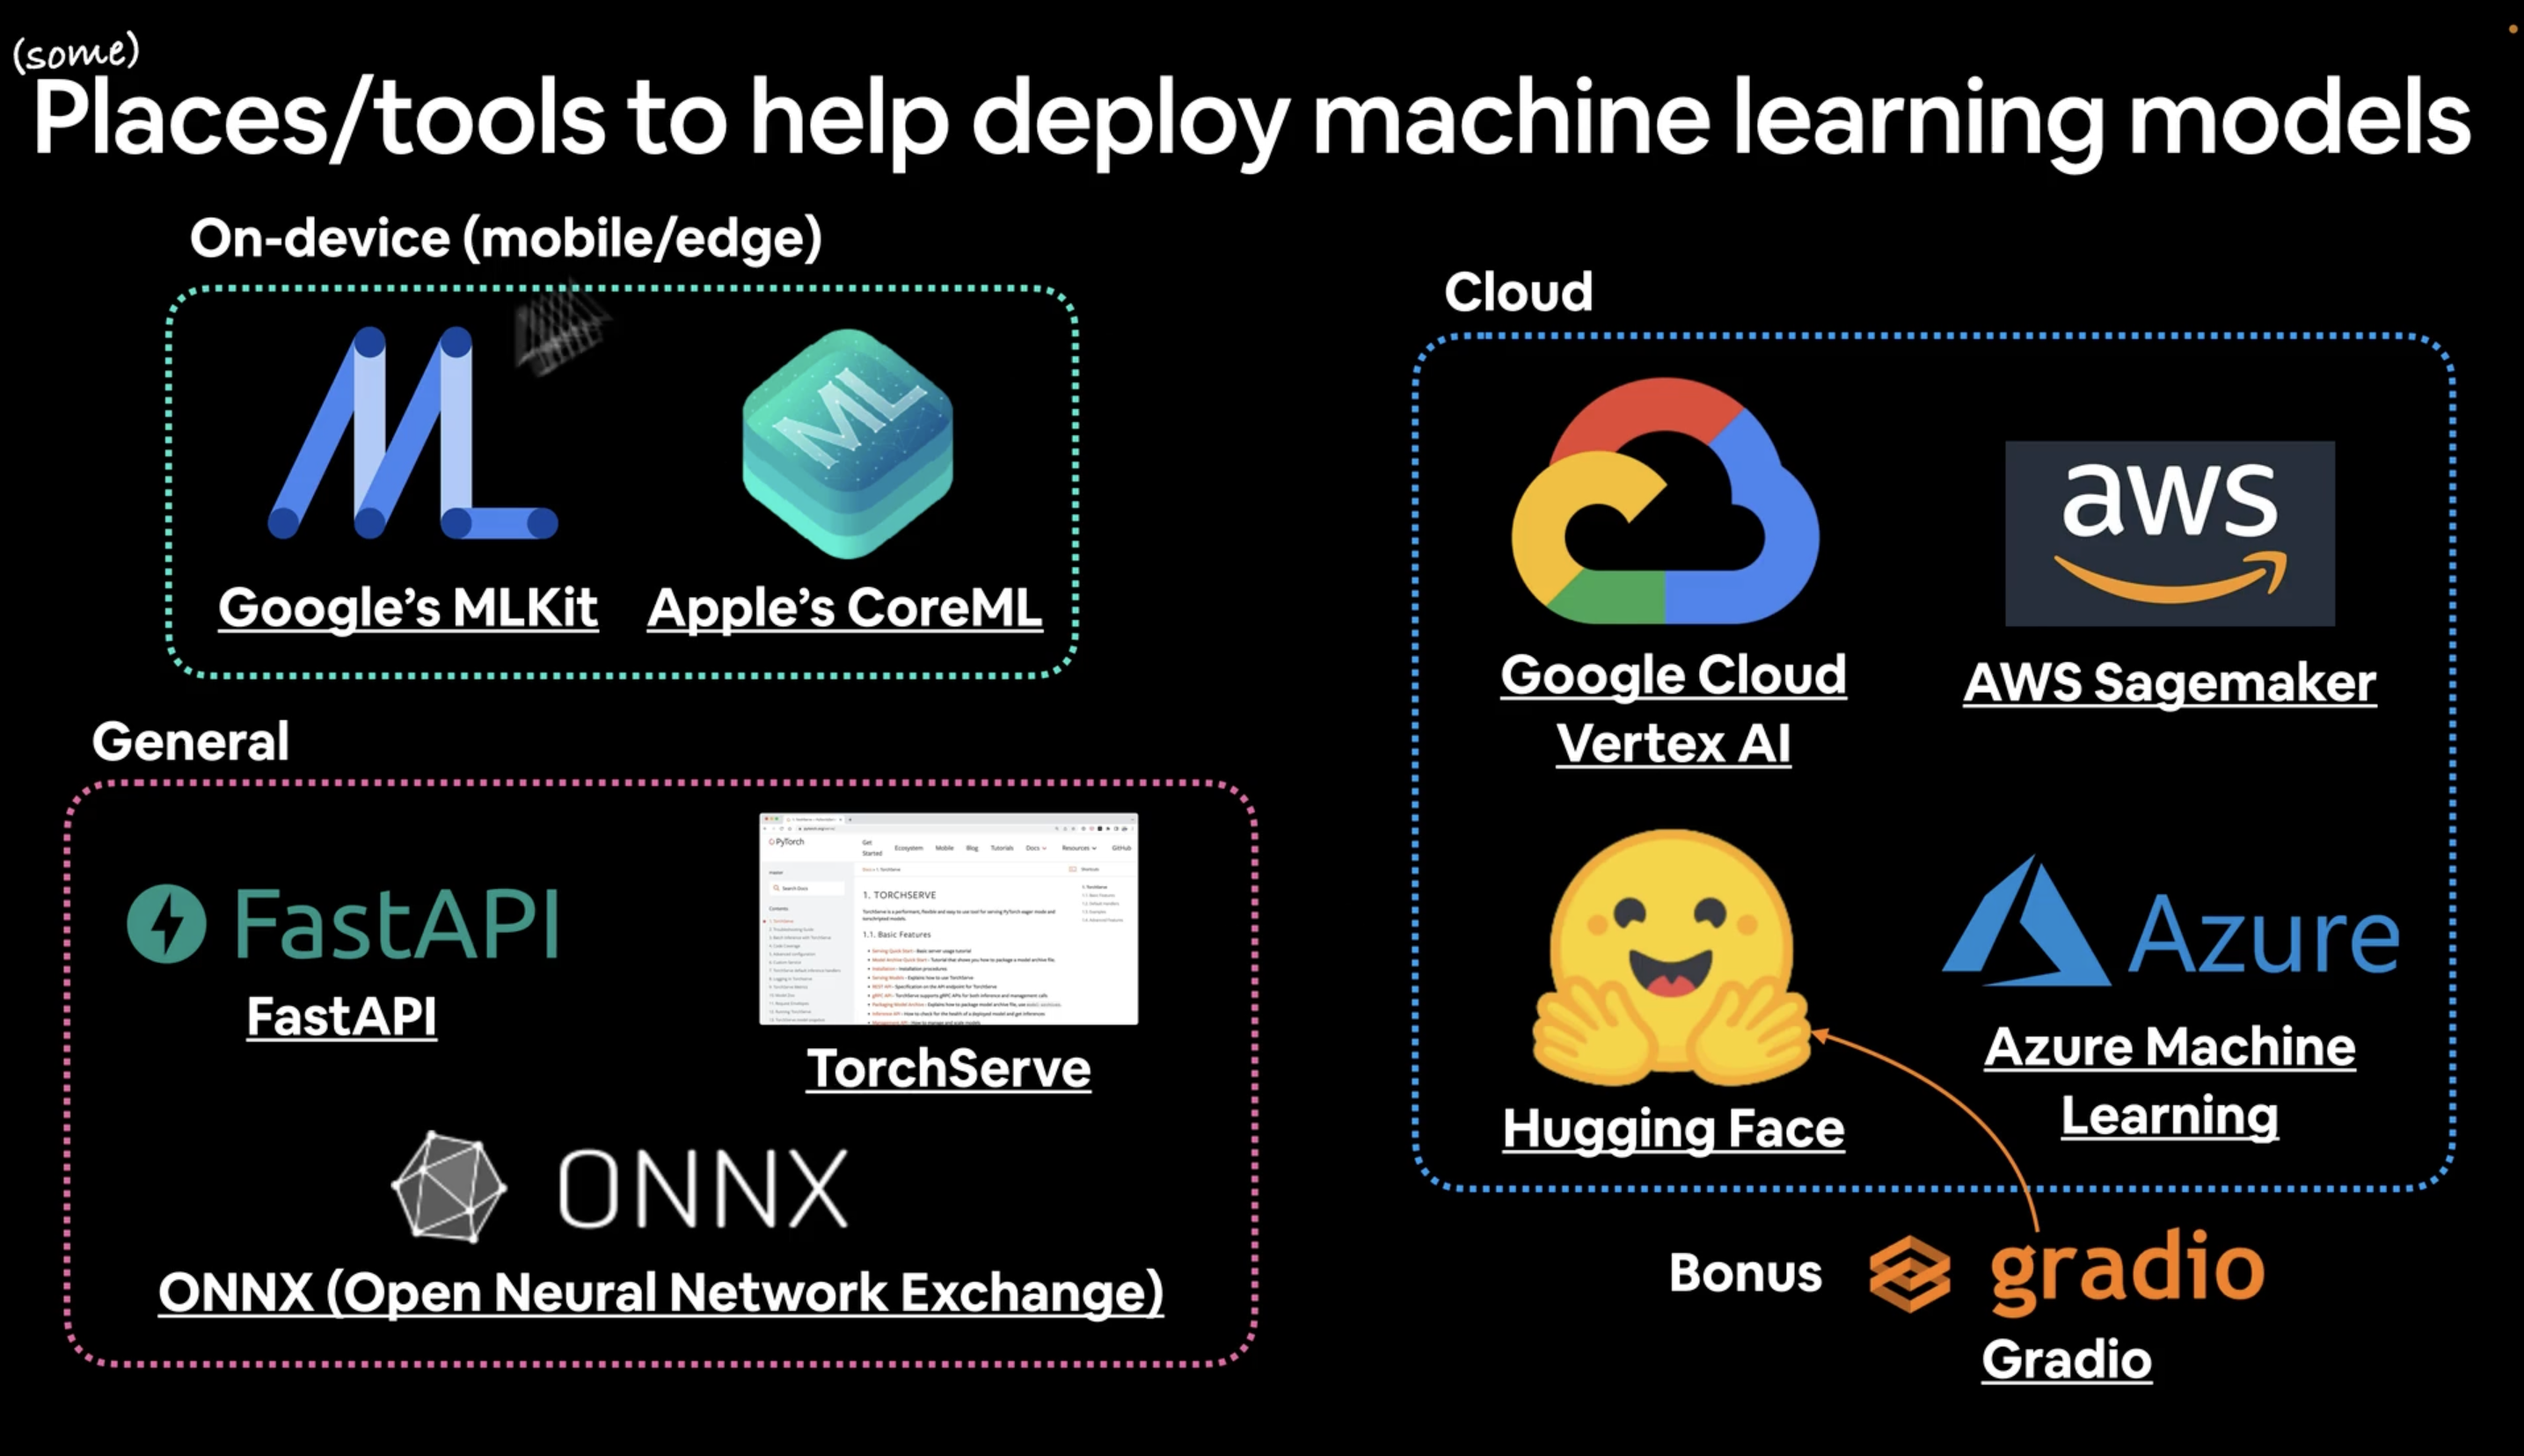

# 1. SETUP and GET DATA

- Dataset to be used: `pizza_steak_sushi_20%`

In [ ]:
import matplotlib.pyplot as plt
import torch
import torchvision

from torch import nn
from torchvision import transforms

from torchinfo import summary

from going_modular.modular_scripts import data_setup, engine
from helper_functions import download_data, set_seeds, plot_loss_curves

device = (
	torch.device("cuda") if torch.cuda.is_available()
	else torch.device("mps") if torch.backends.mps.is_available()
	else torch.device("cpu")
)

print(f"[INFO] Imports sucessful.\n[INFO] Using device: {device}")

In [ ]:
# Download pizza, steak, sushi images from GitHub
data_20_percent_path = download_data(
  	source="https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi_20_percent.zip",
  	destination="pizza_steak_sushi_20_percent"
)

data_20_percent_path

In [ ]:
train_dir = data_20_percent_path / "train"
test_dir = data_20_percent_path / "test"

train_dir, test_dir

# 2. EXPERIMENTATION 

### OUTLINE:

1. What's the most ideal ML model deployment scenario?

2. Where the model is going to go?

3. How the model is going to function?

For **FOODVISION_MINI**: ***A model that performs well and fast***.

-  About 95% accuracy.
- As close to real time (or faster) [With less `Latency` -> Time for inference].

### TWO MODEL EXPERIMENTS:

1. `EffNetB2` feature extractor.

2. `ViT` feature extractor.

# 3.`EffNetB2` FEATURE EXTRACTOR

In [ ]:
effnetB2_weights = torchvision.models.EfficientNet_B2_Weights.DEFAULT
effnetB2_transforms = effnetB2_weights.transforms()

effnetB2 = torchvision.models.efficientnet_b2(weights=effnetB2_weights) # CAN ALSO USE (weights="DEFAULT")

for param in effnetB2.parameters():
	param.requires_grad = False

# summary(
# 	model=effnetB2,
# 	input_size=(1, 3, 224, 224),
# 	col_names=["input_size", "output_size", "num_params", "trainable"],
# 	col_width=24,
# 	row_settings=["var_names"]
# )

In [ ]:
effnetB2.classifier

In [ ]:
set_seeds()

effnetB2.classifier = nn.Sequential(
	nn.Dropout(p=0.3, inplace=True),
	nn.Linear(in_features=1408, out_features=3)
)

# summary(
# 	model=effnetB2,
# 	input_size=(1, 3, 224, 224),
# 	col_names=["input_size", "output_size", "num_params", "trainable"],
# 	col_width=24,
# 	row_settings=["var_names"]
# )

### 3.1 FUNCTIONIZE CREATING EFFNETB2 FEATURE EXTRACTOR

In [ ]:
def create_effnetB2(num_classes:int=3, seed:int=42):
	effnetB2_weights = torchvision.models.EfficientNet_B2_Weights.DEFAULT
	effnetB2_transforms = effnetB2_weights.transforms()

	effnetB2 = torchvision.models.efficientnet_b2(weights=effnetB2_weights)

	for param in effnetB2.parameters():
		param.requires_grad = False

	torch.manual_seed(seed)

	effnetB2.classifier = nn.Sequential(
		nn.Dropout(p=0.3, inplace=True),
		nn.Linear(in_features=1408, out_features=num_classes)
	)

	return effnetB2, effnetB2_transforms

In [ ]:
effnetB2, effnetB2_transforms = create_effnetB2(num_classes=3, seed=42)

In [ ]:
effnetB2_transforms

In [ ]:
# summary(
# 	model=effnetB2,
# 	input_size=(1, 3, 224, 224),
# 	col_names=["input_size", "output_size", "num_params", "trainable"],
# 	col_width=24,
# 	row_settings=["var_names"]
# )

### 3.2 CREATE DATALOADERS

In [ ]:
BATCH_SIZE = 32

train_dataloader_effnetB2, test_dataloader_effnetB2, class_names = data_setup.create_dataloaders(
	train_dir=train_dir,
	test_dir=test_dir,
	transforms=effnetB2_transforms,
  	batch_size=BATCH_SIZE,
    num_workers=0
)

train_dataloader_effnetB2, test_dataloader_effnetB2, class_names

In [ ]:
len(train_dataloader_effnetB2), len(test_dataloader_effnetB2), class_names

In [ ]:
device

### 3.3 TRAIN `EffnetB2`

In [ ]:
from going_modular.modular_scripts import engine

EPOCHS = 10
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
	lr=1e-3,
	params=effnetB2.parameters()
)

set_seeds()
effnetB2_results = engine.train(
	model=effnetB2,
	train_dataloader=train_dataloader_effnetB2,
	test_dataloader=test_dataloader_effnetB2,
	optimizer=optimizer,
	loss_fn=criterion,
	epochs=EPOCHS,
	device=device
)

### 3.4 INSPECT EffnetB2 FEATURE EXTRACTOR'S LOSS CURVES

In [ ]:
plot_loss_curves(results=effnetB2_results)

### 3.5 SAVE THE MODEL

In [ ]:
from going_modular.modular_scripts import utils

utils.save_model(
	model=effnetB2,
	target_dir="../models",
	model_name="09_pretrained_effnetB2_feature_extractor_pizza_steak_sushi_20_percent.pth"
)

### 3.6 CHECK SIZE OF THE MODEL

In [ ]:
import os

effnetB2_saved_model_path = "../models/09_pretrained_effnetB2_feature_extractor_pizza_steak_sushi_20_percent.pth"
effnetB2_size = os.path.getsize(effnetB2_saved_model_path)

print(f"[INFO] EffnetB2 feature extractor size: {effnetB2_size / (1024 * 1024):.2f} MB")

In [ ]:
from pathlib import Path

effnetB2_saved_model_path = "../models/09_pretrained_effnetB2_feature_extractor_pizza_steak_sushi_20_percent.pth"
effnetB2_size = Path(effnetB2_saved_model_path).stat().st_size

print(f"[INFO] EffnetB2 feature extractor size: {effnetB2_size / (1024 * 1024):.2f} MB")

### 3.7 COLLECT EffnetB2 STATS

In [ ]:
# count num params
effnetB2_total_params = sum(torch.numel(param) for param in effnetB2.parameters())
effnetB2_total_params

In [ ]:
effnetB2_stats = {
	"test_loss": effnetB2_results['test_loss'][-1],
	"test_accuracy": effnetB2_results['test_acc'][-1],
	"total_params": effnetB2_total_params,
	"model_size (MB)": round(effnetB2_size / (1024 * 1024), 2)
}

effnetB2_stats

# 4. ViT FEATURE EXTRACTOR

In [ ]:
def create_vitb16(num_classes:int=3, seed:int=42):
	wts = torchvision.models.ViT_B_16_Weights.DEFAULT
	transform = wts.transforms()
	model = torchvision.models.vit_b_16(weights=wts)

	for param in model.parameters():
		param.requires_grad = False

	torch.manual_seed(seed)
	model.heads = nn.Sequential(nn.Linear(in_features=768, out_features=num_classes))

	return transform, model

In [ ]:
# summary(
#   torchvision.models.vit_b_16(weights="DEFAULT"),
#   input_size=(1, 3, 224, 224),
# 	col_names=["input_size", "output_size", "num_params", "trainable"],
# 	col_width=24,
# 	row_settings=["var_names"]
# )

In [ ]:
# torchvision.models.vit_b_16(weights="DEFAULT").heads

In [ ]:
vit_b16_transforms, vit_b16 = create_vitb16(num_classes=3, seed=42) 

In [ ]:
vit_b16_transforms

In [ ]:
from going_modular.modular_scripts import data_setup

BATCH_SIZE = 32

train_dataloader_vit, test_dataloader_vit, _ = data_setup.create_dataloaders(
	train_dir=train_dir,
	test_dir=test_dir,
	transforms=vit_b16_transforms,
	batch_size=BATCH_SIZE,
	num_workers=0
)

train_dataloader_vit, test_dataloader_vit

In [ ]:
from going_modular.modular_scripts import engine

EPOCHS = 10
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
	lr=1e-3,
	params=vit_b16.parameters()
)

set_seeds()
vit_b16_results = engine.train(
	model=vit_b16,
	train_dataloader=train_dataloader_vit,
	test_dataloader=test_dataloader_vit,
	optimizer=optimizer,
	loss_fn=criterion,
	epochs=EPOCHS,
	device=device
)

In [ ]:
plot_loss_curves(results=vit_b16_results)

In [ ]:
from going_modular.modular_scripts import utils

utils.save_model(
	model=vit_b16,
	target_dir="../models",
	model_name="09_pretrained_ViTB16_feature_extractor_pizza_steak_sushi_20_percent.pth"
)

In [ ]:
from pathlib import Path

vitB16_saved_model_path = "../models/09_pretrained_vitB16_feature_extractor_pizza_steak_sushi_20_percent.pth"
vitB16_size = Path(vitB16_saved_model_path).stat().st_size

print(f"[INFO] ViT-B16 feature extractor size: {vitB16_size / (1024 * 1024):.2f} MB")

In [ ]:
vitB16_total_params = sum(torch.numel(params) for params in vit_b16.parameters())
vitB16_total_params

In [ ]:
vitB16_stats = {
	"test_loss": vit_b16_results['test_loss'][-1],
	"test_accuracy": vit_b16_results['test_acc'][-1],
	"total_params": vitB16_total_params,
	"model_size (MB)": round(vitB16_size / (1024 * 1024), 2)
}

vitB16_stats

In [ ]:
import pandas as pd

pd.options.display.float_format = '{:.3f}'.format

effnetB2_df = pd.DataFrame.from_dict(effnetB2_stats, orient="index", columns=['EffnetB2'])
vitB16_df = pd.DataFrame.from_dict(vitB16_stats, orient="index", columns=['VitB16'])

(pd.concat([effnetB2_df, vitB16_df], axis=1))

# 5. MAKING PREDICTIONS WITH MODELS AND TIMING THEM

### 5.1 `function: pred_and_store()`

1. Create a function that takes in a list of paths and a model and series of transforms, list of class names and a device.

2. Create an empty list (to return all predictions later).

3. Loop through target paths.

4. Create an empty dict for each sample (for prediction statistics).

5. Get sample and ground truth class from file paths.

6. Start the prediction timer.

7. Open the image with `PIL.Image.open(path)`.

8. Transform according to model.

9. Prepare model and sample for inference by sending to target device.

10. `model.eval()` and `torch.inference_mode()` -> Forward pass and calculate prob and class.

11. Add prob and class to dict.

12. End the prediction timer and add to dict.

13. See if predicted class matched ground truth.

14. Append the dict to the list

>NOTE: ***A list of dictionaries is a very popular data struture to analyse or compare the results***.

In [ ]:
from typing import Dict, List
from PIL import Image
from pathlib import Path
from torchvision import transforms
from torch import nn
from timeit import default_timer as timer
from tqdm.auto import tqdm

def pred_and_store(
    image_paths: List[str | Path],
    model: nn.Module,
    transforms: transforms,
    class_names: List[str],
    device: torch.device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
) -> List[Dict]:
	prediction_stats = []

	for image_path in tqdm(image_paths, desc="Making predictions", colour="#3c80d9"):
		pred_stat = {}
		ground_truth_class_name = image_path.parent.stem

		start_time = timer()
		image = Image.open(image_path)
		
		transformed_image = transforms(image).unsqueeze(0).to(device)
		model.to(device)

		model.eval()
		with torch.inference_mode():
			pred_logits = model(transformed_image)
			pred_prob = torch.softmax(pred_logits, dim=1)
			pred_class = torch.argmax(pred_prob, dim=1)

		end_time = timer()

		pred_stat["image_path"] = image_path
		pred_stat['pred_prob'] = round(pred_prob.unsqueeze(0).max().item(), 4)
		pred_stat['pred_class'] = class_names[pred_class.item()]
		pred_stat['gound_truth'] = ground_truth_class_name
		pred_stat['pred_time (s)'] = round(end_time - start_time, 4)

		pred_stat['correct'] = ground_truth_class_name == class_names[pred_class.item()]

		prediction_stats.append(pred_stat)

	return prediction_stats


In [ ]:
test_images_paths = list(test_dir.glob("*/*.jpg"))

test_images_paths

### 5.2 PREDICTIONS WITH EFFNETB2

In [ ]:
effnetB2_test_pred_results = pred_and_store(
	test_images_paths, 
  	model=effnetB2,
  	transforms=effnetB2_transforms, 
  	class_names=class_names,
    device=torch.device("cpu") # MAY NOT HAVE ACCESS TO CUDA/MPS DEVICES ALL THE TIME (eg: Mobile)
)

In [ ]:
effnetB2_test_pred_results[:3]

In [ ]:
import pandas as pd

effnetB2_test_pred_results_df = pd.DataFrame(effnetB2_test_pred_results)

effnetB2_test_pred_results_df.head(9)

In [ ]:
effnetB2_test_pred_results_df['correct'].value_counts()

In [ ]:
avg_time_per_pred_effnetB2 = effnetB2_test_pred_results_df['pred_time (s)'].mean()
print(f"[INFO] Average time per prediction(EffnetB2): {round(avg_time_per_pred_effnetB2.item(), 4)}s")

In [ ]:
vitB16_test_pred_results = pred_and_store(
	test_images_paths, 
  	model=vit_b16,
  	transforms=vit_b16_transforms, 
  	class_names=class_names,
    device=torch.device("cpu")
)

In [ ]:
vitB16_test_pred_results[:3]

In [ ]:
import pandas as pd

vitB16_test_pred_results_df = pd.DataFrame(vitB16_test_pred_results)

vitB16_test_pred_results_df.head(9)

In [ ]:
vitB16_test_pred_results_df['correct'].value_counts()

In [ ]:
avg_time_per_pred_vitB16 = vitB16_test_pred_results_df['pred_time (s)'].mean()
print(f"[INFO] Average time per prediction(ViT-B16): {round(avg_time_per_pred_vitB16.item(), 4)}s")

In [ ]:
vitB16_stats['avg_time_per_pred (s)'] = round(avg_time_per_pred_vitB16.item(), 4)
effnetB2_stats['avg_time_per_pred (s)'] = round(avg_time_per_pred_effnetB2.item(), 4)

vitB16_stats, effnetB2_stats

In [ ]:
effnetB2_stats['avg_time_per_pred (s)'] / vitB16_stats['avg_time_per_pred (s)'] * 100

# 6. COMPARING THE STATISTICS OF MODELS

In [ ]:
df = pd.DataFrame([effnetB2_stats, vitB16_stats])

df.insert(
	loc=0,
	column="model_name",
	value=['EffnetB2', 'ViT-B16']
)

df['test_accuracy'] = round(df['test_accuracy'] * 100, 2)

df

In [ ]:
25/44 * 100

In [ ]:
# 30 FPS
1/ 30 # in Seconds

In [ ]:
pd.DataFrame(
	data=df.set_index("model_name").loc["ViT-B16"] / df.set_index("model_name").loc["EffnetB2"],
	columns=["ViT-B16 to EffnetB2 ratios"]
).T

### 6.1 VISUALZING PERFORMANCE VS SPEED TRADEOFF

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))

scatter = ax.scatter(
  	data=df,
    x="avg_time_per_pred (s)",
    y="test_accuracy",
    c=["blue", "orange"],
    s="model_size (MB)"
)

ax.set_title("Foodvision mini Inference speed vs Performance", fontsize=16, fontweight="bold")
ax.set_xlabel("Prediction time per image (seconds)", fontsize=13)
ax.set_ylabel("Test accuracy (%)", fontsize=13)
ax.tick_params(axis="both", labelsize=12)
ax.grid(True)

for index, row in df.iterrows():
	ax.annotate(
		text=row["model_name"],
		xy=[row['avg_time_per_pred (s)'] + 6e-4, row['test_accuracy'] - 24e-3], # WHERE TO DISPLAY THE NAMES( XY COORDINATE)
		size=12
	)

handles, labels = scatter.legend_elements(prop="sizes", alpha=0.5)
model_size_legend = ax.legend(handles, labels, loc="lower right", title="Model size (MB)", fontsize=13)

plt.savefig("../images/09-speed_vs_inference.png")

plt.show()

# 7. MAKING A `GRADIO` DEMO:

In [ ]:
try:
	import gradio as gr
except ModuleNotFoundError:
	print(f"[INFO] Gradio not found. Downloading...")
	%pip install gradio -q
	print(f"[INFO] Gradio downloaded\n")
	import gradio as gr
	print(f"[INFO] Using gradio: {gr.__version__}")

### 7.1 CREATE A FUNCTION TO MAP INPUTS AND OUTPUTS

In [ ]:
effnetB2 = effnetB2.to(torch.device("cpu"))

next(iter(effnetB2.parameters())).device

In [ ]:
from typing import Tuple, Dict
from timeit import default_timer as timer

def predict(img) -> Tuple[Dict, float]:
	start_time = timer()

	img = effnetB2_transforms(img).unsqueeze(0)

	effnetB2.eval()

	with torch.inference_mode():
		pred_probs = torch.softmax(effnetB2(img), dim=1).squeeze(0)

	pred_labels_and_scores = {class_names[i]: float(prob) for i, prob in enumerate(pred_probs)}

	pred_time = round(timer() - start_time, 4)

	return pred_labels_and_scores, pred_time

In [ ]:
import random
from PIL import Image

random_image_path = random.sample(test_images_paths, k=1)[0]
random_image = Image.open(random_image_path)

print(f"[INFO] Predicting on image at path: {random_image_path} \n[Image]:")
plt.figure(figsize=(6, 4))
plt.imshow(random_image.resize(size=(random_image.size[0], random_image.size[1])))
plt.axis("off")
plt.show()

pred_dict, pred_time = predict(random_image)

pred_dict, pred_time

### 7.2 CREATING A LIST OF EXAMPLES

In [ ]:
examples_list = [[str(filepath)] for filepath in random.sample(test_images_paths, k=3)]

examples_list

### 7.3 CREATE A DEMO USING `gradio.Interface`

In [ ]:
import gradio as gr

title = "Foodvision Mini (3 classes: 🍕 🥩 🍣)"

description = "An [EfficientNetB2](https://docs.pytorch.org/vision/main/models/generated/torchvision.models.efficientnet_b2.html) feature extractor to classify images as pizza steak sushi."

# article = "Where model was created"

demo = gr.Interface(
	fn=predict,
	inputs=gr.Image(type="pil"),
	outputs=[
    	gr.Label(num_top_classes=3, label="Predictions"),
		gr.Number(label="Prediction time (s)")
    ],
    examples=examples_list,
    title=title,
    description=description,
    # article=article,
)

demo.launch()

# 8. UPLOADING TO HUGGING FACE SPACES

### 8.1 FILE STRUCTURE:

```text
demos/
└── foodvision_mini/
    ├── 09_pretrained_effnetb2_feature_extractor_pizza_steak_sushi_20_percent.pth
    ├── app.py
    ├── examples/
    │   ├── example_1.jpg
    │   ├── example_2.jpg
    │   └── example_3.jpg
    ├── model.py
    └── requirements.txt
```

In [ ]:
import shutil
from pathlib import Path

demo_path = Path("../demo/foodvision_mini")

# REMOVE FILES THAT MIGHT EXIST AND CREATE NEW DIR
if demo_path.exists():
	shutil.rmtree(demo_path)
	demo_path.mkdir(parents=True, exist_ok=True)
else:
	demo_path.mkdir(parents=True, exist_ok=True)

shutil.copy2(
	src="../Models/09_pretrained_effnetB2_feature_extractor_pizza_steak_sushi_20_percent.pth",
	dst=demo_path
)

In [ ]:
demo_examples_path = Path(demo_path, "examples")

demo_examples_path.mkdir(parents=True, exist_ok=True)

examples_path = [
	Path("../data/pizza_steak_sushi_20_percent/test/pizza/648055.jpg"),
	Path("../data/pizza_steak_sushi_20_percent/test/steak/219196.jpg"),
	Path("../data/pizza_steak_sushi_20_percent/test/sushi/511818.jpg")
]

for image_path in examples_path:
	print(f"[INFO] Copying {str(image_path)} to {demo_examples_path / image_path.name}")
	shutil.copy2(image_path, demo_examples_path)

In [ ]:
import os

examples_list = [["examples/" + example] for example in os.listdir(demo_examples_path)]
examples_list

In [ ]:
os.listdir(demo_examples_path)

### 8.2 `model.py` FOR LOADING THE MODEL FROM `state_dict`

In [ ]:
%%writefile ../demo/foodvision_mini/model.py
import torch
import torchvision
from torch import nn

def create_effnetB2(num_classes:int=3, seed:int=42):
	effnetB2_weights = torchvision.models.EfficientNet_B2_Weights.DEFAULT
	effnetB2_transforms = effnetB2_weights.transforms()

	effnetB2 = torchvision.models.efficientnet_b2(weights=effnetB2_weights)

	for param in effnetB2.parameters():
		param.requires_grad = False

	torch.manual_seed(seed)

	effnetB2.classifier = nn.Sequential(
		nn.Dropout(p=0.3, inplace=True),
		nn.Linear(in_features=1408, out_features=num_classes)
	)

	return effnetB2, effnetB2_transforms

In [ ]:
class_names

### 8.7 CREATE `app.py` FOR GRADIO

In [ ]:
%%writefile ../demo/foodvision_mini/app.py
import gradio as gr
import os
import torch

from model import create_effnetB2
from timeit import default_timer as timer
from typing import Tuple, Dict

class_names = ['pizza', 'steak', 'sushi']

effnetB2, effnetB2_transforms = create_effnetB2(num_classes=len(class_names))

effnetB2.load_state_dict(
	torch.load(
    	f="09_pretrained_effnetB2_feature_extractor_pizza_steak_sushi_20_percent.pth",
		map_location=torch.device("cpu")
	)
)

def predict(img) -> Tuple[Dict, float]:
	start_time = timer()

	img = effnetB2_transforms(img).unsqueeze(0)

	effnetB2.eval()

	with torch.inference_mode():
		pred_probs = torch.softmax(effnetB2(img), dim=1).squeeze(0)

	pred_labels_and_scores = {class_names[i]: float(prob) for i, prob in enumerate(pred_probs)}

	pred_time = round(timer() - start_time, 4)

	return pred_labels_and_scores, pred_time

title = "Foodvision Mini (3 classes: 🍕 🥩 🍣)"
description = "An [EfficientNetB2](https://docs.pytorch.org/vision/main/models/generated/torchvision.models.efficientnet_b2.html) feature extractor to classify images as pizza steak sushi."
examples_list = [["examples/" + example] for example in os.listdir("examples")]

demo = gr.Interface(
	fn=predict,
	inputs=gr.Image(type="pil"),
	outputs=[
    	gr.Label(num_top_classes=3, label="Predictions"),
		gr.Number(label="Prediction time (s)")
    ],
    examples=examples_list,
    title=title,
    description=description,
)

demo.launch()

In [ ]:
%%writefile ../demo/foodvision_mini/requirements.txt
torch
torchvision
gradio

# 9. DEPLOY TO HF SPACES

In [ ]:
!ls ../demo/foodvision_mini

In [ ]:
# !cd ../demo/foodvision_mini && zip ../foodvision_mini.zip * -x "*.pyc" "*.ipynb" "__pycache__" "*ipynb_checkpoints*"

# 10. FOODVISION BIG

- With `food101` dataset. [https://docs.pytorch.org/vision/main/generated/torchvision.datasets.Food101.html]

- Introduce some `data augmentation` techniques.

- This is because with larger datasets and larger models, ***overfitting*** becomes more of a problem.

### 10.1 CREATE THE MODEL AND TRANSFORMS REQUIRED

In [ ]:
effnetB2_food101, effnetB2_transforms = create_effnetB2(num_classes=101)

In [ ]:
summary(
	model=effnetB2_food101,
	input_size=(1, 3, 224, 224),
	col_names=["input_size", "output_size", "num_params", "trainable"],
	col_width=24,
	row_settings=["var_names"]
)

In [ ]:
food101_train_transforms = torchvision.transforms.Compose(
	[
		torchvision.transforms.TrivialAugmentWide(num_magnitude_bins=31),
		effnetB2_transforms
	]
)

food101_test_transforms = effnetB2_transforms

food101_train_transforms, food101_test_transforms

### 10.2 GET THE DATASET

In [ ]:
from torchvision import datasets
from pathlib import Path

data_dir = Path("../data")

train_data = datasets.Food101(
	root=data_dir,
	split="train",
	transform=food101_train_transforms,
	download=True,
)

test_data = datasets.Food101(
	root=data_dir,
	split="test",
	transform=food101_test_transforms,
	download=True,
)

**NOTE**: `split="train"` doesn't mean "create a train folder; it means "when this Dataset object is indexed, give the samples listed in the official training metadata (`train.txt` / `train.json`)."

- The dataset archive contains the **all of** dataset's image files, and torchvision's download/extraction process downloads the dataset package rather than selectively fetching only the test or train images.

In [ ]:
# torchvision.datasets.Food101?

In [ ]:
750*101, 250*101, 750*101 + 250*101

In [ ]:
len(train_data), len(test_data)

In [ ]:
train_data.classes[:10]

### 10.3 SPLIT 20% OF DATA

In [ ]:
0.2*len(train_data), 0.2*len(test_data), 0.2*len(train_data) + 0.2*len(test_data)

In [ ]:
from torch.utils.data import random_split

def split_dataset(
    dataset: torchvision.datasets,
    split_size: float=0.2,
    seed: int=42
):
	# CREATE SPLIT LENGTHS BASED ON DATASET LENGTH
	length_1 = int(len(dataset) * split_size)
	length_2 = len(dataset) - length_1

	print(f"[INFO] Splitting dataset of length {len(dataset)} into splits of size: {length_1} and {length_2}")

	random_split_1, random_split_2 = random_split(
		dataset=dataset,
		lengths=[length_1, length_2],
		generator=torch.manual_seed(seed)
	)

	return random_split_1, random_split_2

In [ ]:
# torch.Generator?

In [ ]:
# torch.utils.data.random_split?

In [ ]:
train_data_food101_20_percent, _ = split_dataset(
	dataset=train_data,
	split_size=0.2
)

test_data_food101_20_percent, _ = split_dataset(
	dataset=test_data,
	split_size=0.2
)

In [ ]:
len(train_data_food101_20_percent), len(test_data_food101_20_percent)

In [ ]:
train_data_food101_20_percent[0]

### 10.4 CREATE DATALOADERS

In [ ]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_dataloader_food101_20_percent = DataLoader(
	dataset=train_data_food101_20_percent,
	batch_size=BATCH_SIZE,
	shuffle=True
)

test_dataloader_food101_20_percent = DataLoader(
  	dataset=test_data_food101_20_percent,
	batch_size=BATCH_SIZE,
)

train_dataloader_food101_20_percent, test_dataloader_food101_20_percent

In [ ]:
len(train_dataloader_food101_20_percent), len(test_dataloader_food101_20_percent)

### 10.5 TRAINING

In [ ]:
device

#### LABEL SMOOTHING:

- A regularization technique that may help to prevent overfitting.

- Eg: 5 classes:

Without label smoothing:
```py
[0.00, 0.00, 0.00, 0.99, 0.00]
```
- Model may become overconfident on a particular class.

With label smoothing:
```py
[0.01, 0.01, 0.01, 0.96, 0.01]
```
- Not exact values, just an idea, it assigns some probability to other classes too.

In [ ]:
from going_modular.modular_scripts import engine

NUM_EPOCHS = 5
loss_fn = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.Adam(
	lr=1e-3,
	params=effnetB2_food101.parameters()
)

set_seeds()
foodvision_big_effnetB2_results = engine.train(
	model=effnetB2_food101,
	train_dataloader=train_dataloader_food101_20_percent,
  	test_dataloader=test_dataloader_food101_20_percent,
	optimizer=optimizer,
	loss_fn=loss_fn,
	epochs=NUM_EPOCHS,
	device=device
)

In [ ]:
19.37 * 60 / 5

### 10.6 PLOT LOSS CURVES

In [ ]:
from helper_functions import plot_loss_curves

plot_loss_curves(foodvision_big_effnetB2_results)

### 10.7 SAVE AND LOAD FOODVISION-BIG

In [ ]:
from going_modular.modular_scripts import utils

food101_model_name = "09_effnetB2_feature_extractor_food101_20_percent.pth"

utils.save_model(
	model=effnetB2_food101,
	target_dir="../models",
	model_name=food101_model_name
)

### 10.7 LOAD TRAINED MODEL

In [ ]:
loaded_effnetB2_food101, effnetB2_transforms = create_effnetB2(num_classes=101)

loaded_effnetB2_food101.load_state_dict(
	torch.load("../models/09_effnetB2_feature_extractor_food101_20_percent.pth")
)

### 10.8 CHECK THE MODEL SIZE

In [ ]:
from pathlib import Path

trained_food101_effnetB2_size = Path("../models", food101_model_name).stat().st_size // (1024 ** 2)
print(f"[INFO] Pretrained EffnetB2 feature extractor Food101 model size: ~{trained_food101_effnetB2_size} MB")

# 11. UPLOADING FOODVISION BIG TO HF SPACES

```text
demos/
  foodvision_big/
    09_pretrained_effnetb2_feature_extractor_food101_20_percent.pth
    app.py
    class_names.txt
    examples/
      example_1.jpg
    model.py
    requirements.txt
```

In [ ]:
from pathlib import Path

foodvision_big_demo_path = Path("../demo/foodvision_big")

foodvision_big_demo_path.mkdir(parents=True, exist_ok=True)

(foodvision_big_demo_path / "examples").mkdir(exist_ok=True, parents=True)

In [ ]:
!ls "../demo/foodvision_big"

### 11.1 ADDING CUSTOM IMAGES TO EXAMPLES

In [ ]:
import requests

image_urls = [
	"https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcTcQu4mVss1DPsiPEcf5qj48GJwo2a9OUkQrjjG8Ze9WA&s=10",
	"https://www.wellplated.com/wp-content/uploads/2023/03/Easy-Grilled-Salmon-500x500.jpg",
	"https://farahjeats.com/wp-content/uploads/2023/01/IMG_4632-768x1024.jpg"
]

names = [
	"chocolate_mousse",
	"grilled_salmon",
	"miso_soup"
]

for url, filename in zip(image_urls, names):
	res = requests.get(url)
	res.raise_for_status()
	with open(foodvision_big_demo_path / "examples" / f"{filename}.jpeg", "wb")as f:
		f.write(res.content)

In [ ]:
!mv ../models/09_effnetB2_feature_extractor_food101_20_percent.pth ../demo/foodvision_big

In [ ]:
food101_class_names = train_data.classes

food101_class_names[:10]

In [ ]:
foodvision_big_class_names_path = foodvision_big_demo_path / "class_names.txt"
foodvision_big_class_names_path

In [ ]:
with open(foodvision_big_class_names_path, "w") as f:
	print(f"[INFO] Writing food101 class names to: {foodvision_big_class_names_path}")
	f.write("\n".join(food101_class_names))

In [ ]:
with open(foodvision_big_class_names_path, "r") as f:
	food101_class_names_loaded = [food.strip() for food in f.readlines()]

food101_class_names_loaded

In [ ]:
%%writefile ../demo/foodvision_big/model.py
import torch
import torchvision
from torch import nn

def create_effnetB2(num_classes:int=3, seed:int=42):
	effnetB2_weights = torchvision.models.EfficientNet_B2_Weights.DEFAULT
	effnetB2_transforms = effnetB2_weights.transforms()

	effnetB2 = torchvision.models.efficientnet_b2(weights=effnetB2_weights)

	for param in effnetB2.parameters():
		param.requires_grad = False

	torch.manual_seed(seed)

	effnetB2.classifier = nn.Sequential(
		nn.Dropout(p=0.3, inplace=True),
		nn.Linear(in_features=1408, out_features=num_classes)
	)

	return effnetB2, effnetB2_transforms

In [165]:
%%writefile ../demo/foodvision_big/requirements.txt
torch
torchvision
gradio
spaces

Overwriting ../demo/foodvision_big/requirements.txt


In [ ]:
%%writefile ../demo/foodvision_big/app.py
import gradio as gr
import torch
import os
from model import create_effnetB2
from timeit import default_timer as timer
from typing import Tuple, Dict

with open("class_names.txt", "r") as f:
	class_names = [class_name.strip() for class_name in f.readlines()]

effnetB2, effnetB2_transforms = create_effnetB2(num_classes=101)

effnetB2.load_state_dict(
	torch.load(
		f="09_effnetB2_feature_extractor_food101_20_percent.pth",
		map_location=torch.device("cpu")
	),
)

def predict(img) -> Tuple[Dict, float]:
	start_time = timer()

	img = effnetB2_transforms(img).unsqueeze(0)

	effnetB2.eval()
	with torch.inference_mode():
		pred_probs = torch.softmax(effnetB2(img), dim=1).squeeze(0)

	pred_labels_and_scores = {class_names[i]: score.item() for i, score in enumerate(pred_probs)}

	pred_time = timer() - start_time

	return pred_labels_and_scores, pred_time

title = "Foodvision (food101)"
description = "An [EfficientNetB2](https://docs.pytorch.org/vision/main/models/generated/torchvision.models.efficientnet_b2.html) feature extractor to classify food images of 101 classes from `FOOD101` dataset."
examples_list = [["examples/" + example] for example in os.listdir("examples")]

examples_list = [["examples/" + example_path] for example_path in os.listdir("examples")]

demo = gr.Interface(
	fn=predict,
	inputs=gr.Image(type="pil"),
	outputs=[
		gr.Label(num_top_classes=5, label="Predictions"),
		gr.Number(label="Prediction time (s)")
	],
	examples=examples_list,
	title=title,
	description=description
)

demo.launch()

Writing ../demo/foodvision_big/app.py


In [161]:
[["examples/" + example_path] for example_path in os.listdir("../demo/foodvision_big/examples")]

[['examples/miso_soup.jpeg'],
 ['examples/chocolate_mousse.jpeg'],
 ['examples/grilled_salmon.jpeg']]

In [166]:
!cd ../demo/foodvision_big && zip ../foodvision_big.zip * -x "*.pyc" "*.ipynb" "__pycache__" "*ipynb_checkpoints*"

  adding: 09_effnetB2_feature_extractor_food101_20_percent.pth (deflated 8%)
  adding: __pycache__/ (stored 0%)
  adding: app.py (deflated 50%)
  adding: class_names.txt (deflated 48%)
  adding: examples/ (stored 0%)
  adding: model.py (deflated 47%)
  adding: requirements.txt (deflated 3%)


# DEPLOYED APP IN HF SPACES:

`https://huggingface.co/spaces/kb0968237/foodvision_Food101`